In [21]:
import numpy as np
import matplotlib.pyplot as plt
import random
import pandas as pd
import importlib

In [34]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

import encoder_classifier as ec
importlib.reload(ec)

<module 'encoder_classifier' from 'c:\\Users\\Utente\\Desktop\\uni\\MAGISTRALE\\___TESI_magistrale\\github\\prove_modelli\\encoder_classifier.py'>

# 0. DATA LOADING

In [23]:
# -------------       
# DATASET PATHS
# -------------
train_path = r"C:\Users\Utente\Desktop\uni\MAGISTRALE\___TESI_magistrale\github\prove_modelli\FordA\TRAIN_set.csv"
test_path = r"C:\Users\Utente\Desktop\uni\MAGISTRALE\___TESI_magistrale\github\prove_modelli\FordA\TEST_set.csv"

# -------------------------
# TRAINING DATA PREPARATION
# -------------------------
train_dataset, train_loader, waves_train, labels_train = ec.dataload(train_path)


# ---------------------
# TEST DATA PREPARATION
# ---------------------
test_dataset, test_loader, waves_test, labels_test = ec.dataload(test_path)


# ---------------------------
# TEST PLOT TO VISUALISE DATA
# ---------------------------
# ec.plot_wave(waves_train)
# ec.plot_wave(waves_test)

This function loads the data from the specified path and returns (in this order): 
 - the dataset - the loader - the waves and labels
Loading data from C:\Users\Utente\Desktop\uni\MAGISTRALE\___TESI_magistrale\github\prove_modelli\FordA\TRAIN_set.csv...
Data loaded successfully. Waves shape: torch.Size([3601, 1, 500]), Labels shape: torch.Size([3601])
This function loads the data from the specified path and returns (in this order): 
 - the dataset - the loader - the waves and labels
Loading data from C:\Users\Utente\Desktop\uni\MAGISTRALE\___TESI_magistrale\github\prove_modelli\FordA\TEST_set.csv...
Data loaded successfully. Waves shape: torch.Size([1320, 1, 500]), Labels shape: torch.Size([1320])


# 1. AUTOENCODER training + test

Epoch [1/500] - Average loss: 0.3767
Epoch [2/500] - Average loss: 0.1094
Epoch [3/500] - Average loss: 0.0663
Epoch [4/500] - Average loss: 0.0494
Epoch [5/500] - Average loss: 0.0369
Epoch [6/500] - Average loss: 0.0256
Epoch [7/500] - Average loss: 0.0210
Epoch [8/500] - Average loss: 0.0180
Epoch [9/500] - Average loss: 0.0143
Epoch [10/500] - Average loss: 0.0137
Epoch [11/500] - Average loss: 0.0124
Epoch [12/500] - Average loss: 0.0117
Epoch [13/500] - Average loss: 0.0101
Epoch [14/500] - Average loss: 0.0095
Epoch [15/500] - Average loss: 0.0109
Epoch [16/500] - Average loss: 0.0149
Epoch [17/500] - Average loss: 0.0082
Epoch [18/500] - Average loss: 0.0076
Epoch [19/500] - Average loss: 0.0072
Epoch [20/500] - Average loss: 0.0083
Epoch [21/500] - Average loss: 0.0070
Epoch [22/500] - Average loss: 0.0072
Epoch [23/500] - Average loss: 0.0073
Epoch [24/500] - Average loss: 0.0076
Epoch [25/500] - Average loss: 0.0072
Epoch [26/500] - Average loss: 0.0071
Epoch [27/500] - Aver

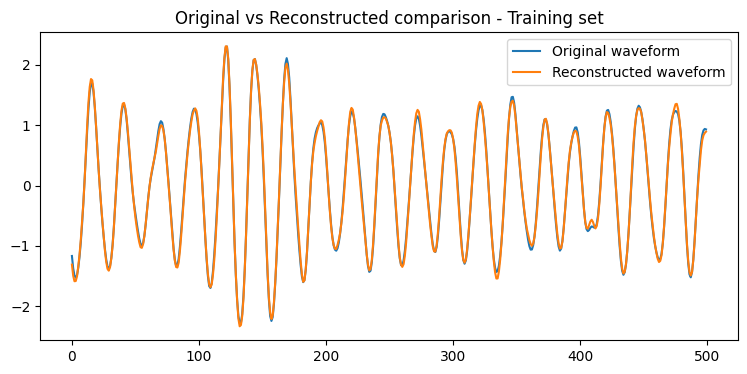

In [24]:
# ------------------------------------
# MODEL TRAINING for the FordA dataset
# ------------------------------------

FordA_model = ec.AutoEncoder()

# This comand put the model in training mode 
# that means that some mathematichal structures are behaving in a specific mode
FordA_model.train() 

trained_ae_FordA = ec.train_autoencoder(FordA_model, train_loader, epochs=500)

Recontruction - Test result: Average loss: 0.0051


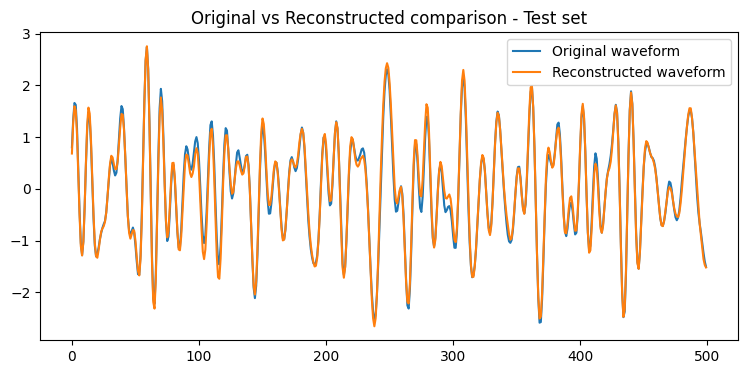

In [25]:
# -----------------------
# TEST of the FordA_model
# -----------------------

tested_ae_FordA = ec.test_autoencoder(trained_ae_FordA, test_loader)


# 2. CLASSIFIER

In [26]:
# -----------------------
# TRAIN of the CLASSIFIER
# -----------------------

FordA_classifier = ec.Classifier()

classifier_FordA = ec.train_classifier(trained_ae_FordA, FordA_classifier, train_loader, epochs=500)

Epoch [1/500] - Loss: 0.6935 - Accuracy: 50.71%
Epoch [2/500] - Loss: 0.6861 - Accuracy: 53.49%
Epoch [3/500] - Loss: 0.6753 - Accuracy: 55.46%
Epoch [4/500] - Loss: 0.6491 - Accuracy: 61.43%
Epoch [5/500] - Loss: 0.5895 - Accuracy: 67.68%
Epoch [6/500] - Loss: 0.5560 - Accuracy: 69.95%
Epoch [7/500] - Loss: 0.5240 - Accuracy: 73.84%
Epoch [8/500] - Loss: 0.5004 - Accuracy: 74.95%
Epoch [9/500] - Loss: 0.4919 - Accuracy: 76.20%
Epoch [10/500] - Loss: 0.4618 - Accuracy: 78.62%
Epoch [11/500] - Loss: 0.4641 - Accuracy: 78.42%
Epoch [12/500] - Loss: 0.4409 - Accuracy: 79.89%
Epoch [13/500] - Loss: 0.4344 - Accuracy: 79.62%
Epoch [14/500] - Loss: 0.4121 - Accuracy: 81.70%
Epoch [15/500] - Loss: 0.4091 - Accuracy: 81.76%
Epoch [16/500] - Loss: 0.4050 - Accuracy: 81.64%
Epoch [17/500] - Loss: 0.3914 - Accuracy: 83.17%
Epoch [18/500] - Loss: 0.3720 - Accuracy: 83.78%
Epoch [19/500] - Loss: 0.3754 - Accuracy: 83.09%
Epoch [20/500] - Loss: 0.3725 - Accuracy: 82.95%
Epoch [21/500] - Loss: 0.3495

In [35]:
# ----------------------
# TEST of the CLASSIFIER
# ----------------------

tested_classifier_FordA = ec.test_classifier(trained_ae_FordA, classifier_FordA, test_loader)


Classification - Test result: 
Average loss: 0.5223 
Accuracy: 86.14%
